In [1]:
# ================================================================
# 🚀 END-TO-END SALES FORECASTING & DEMAND INTELLIGENCE SYSTEM
# Tasks 1-6 | SARIMA + Prophet + XGBoost | Anomaly Detection | Clustering
# ================================================================

!pip install -q kagglehub prophet xgboost statsmodels scikit-learn plotly --upgrade

import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import warnings, glob
warnings.filterwarnings("ignore")

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.statespace.sarimax import SARIMAX
from prophet import Prophet
from xgboost import XGBRegressor
from sklearn.ensemble import IsolationForest
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (14, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.titleweight"] = "bold"
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sklearn-compat 0.1.3 requires scikit-learn<1.7,>=1.2, but you have scikit-learn 1.9.0 which is incompatible.


100%|██████████| 480k/480k [00:01<00:00, 459kB/s]

Extracting files...


100%|██████████| 381k/381k [00:01<00:00, 385kB/s]

Extracting files...


Superstore shape: (9800, 18)
Video Game Sales shape: (16598, 11)
Missing values:
 Postal Code    11
dtype: int64
Duplicate rows: 0


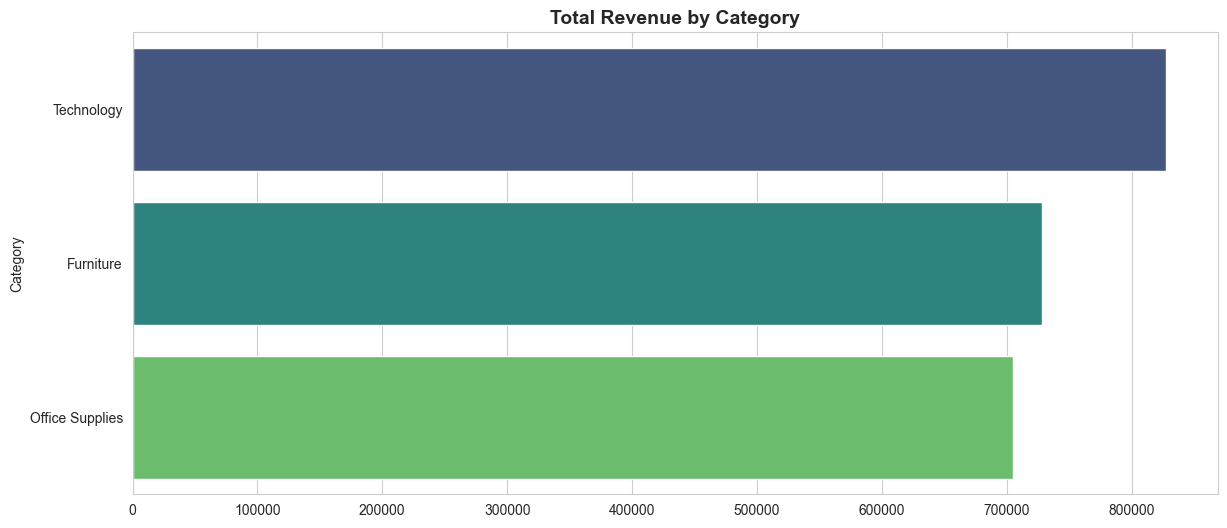

👉 Highest revenue category: Technology ($827,456)


Growth volatility by region (lower = more consistent):
 Region
East       0.017939
Central    0.253453
West       0.257431
South      0.371249
dtype: float64
👉 Most consistent region: East


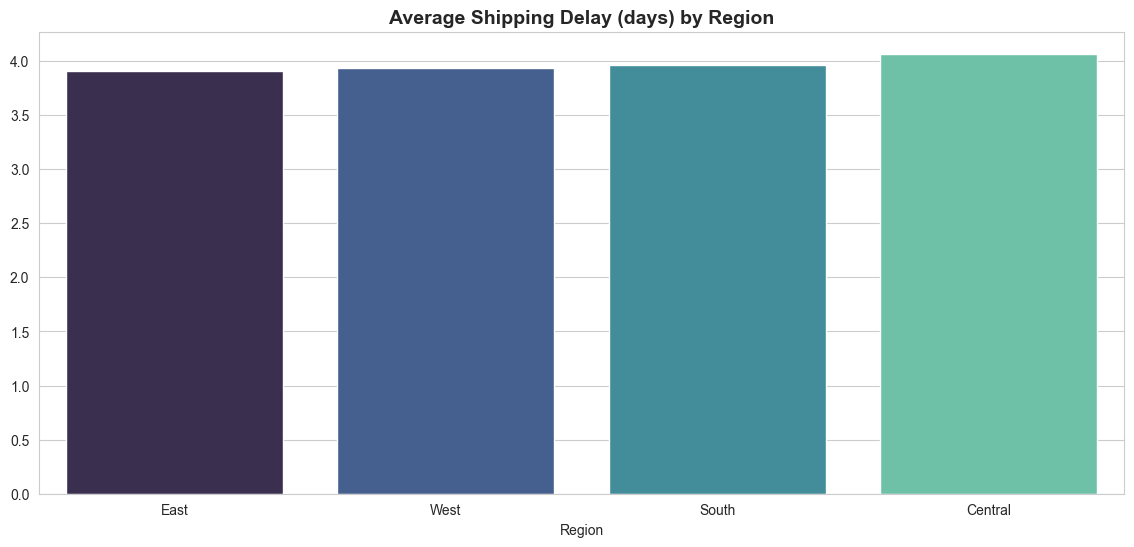

Overall avg ship delay: 3.96 days
Region
East       3.910233
West       3.930255
South      3.961202
Central    4.065876
Name: ShipDelay, dtype: float64


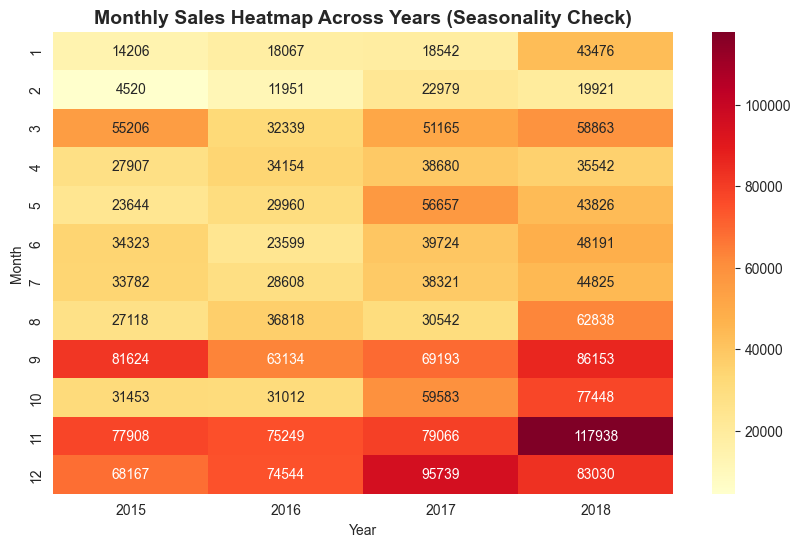

   Year        Sales  Global_Sales
0  2015  479856.2081        264.44
1  2016  459436.0054         70.93
2  2017  600192.5500          0.05


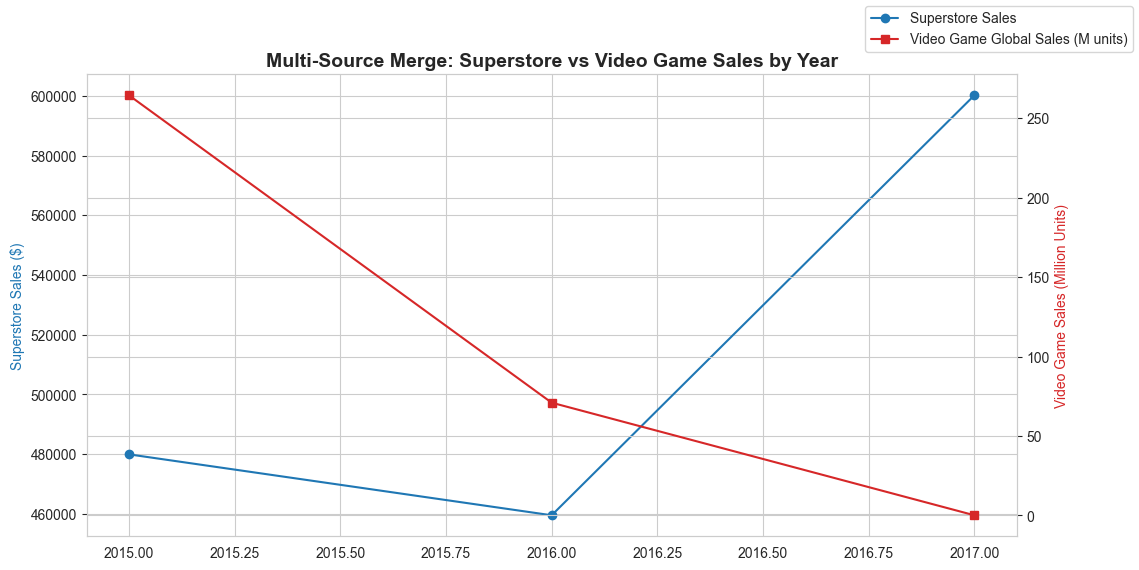

In [2]:

# ================================================================
# TASK 1 — DATA LOADING, MERGING & DEEP EXPLORATION
# ================================================================

path_sales = kagglehub.dataset_download("rohitsahoo/sales-forecasting")
path_games = kagglehub.dataset_download("gregorut/videogamesales")

sales_csv = glob.glob(f"{path_sales}/*.csv")[0]
games_csv = glob.glob(f"{path_games}/*.csv")[0]

df = pd.read_csv(sales_csv, encoding="latin1")
games = pd.read_csv(games_csv, encoding="latin1")

print("Superstore shape:", df.shape)
print("Video Game Sales shape:", games.shape)
df.head()

# ---- Parse dates & engineer time features ----
df["Order Date"] = pd.to_datetime(df["Order Date"], dayfirst=True, errors="coerce")
df["Ship Date"]  = pd.to_datetime(df["Ship Date"], dayfirst=True, errors="coerce")
df["Year"] = df["Order Date"].dt.year
df["Month"] = df["Order Date"].dt.month
df["MonthName"] = df["Order Date"].dt.month_name()
df["Week"] = df["Order Date"].dt.isocalendar().week
df["DayOfWeek"] = df["Order Date"].dt.day_name()
df["Quarter"] = df["Order Date"].dt.quarter

def get_season(m):
    if m in [12,1,2]: return "Winter"
    elif m in [3,4,5]: return "Spring"
    elif m in [6,7,8]: return "Summer"
    else: return "Autumn"

df["Season"] = df["Month"].apply(get_season)
df["ShipDelay"] = (df["Ship Date"] - df["Order Date"]).dt.days

# ---- Missing values / duplicates ----
print("Missing values:\n", df.isnull().sum()[df.isnull().sum() > 0])
print("Duplicate rows:", df.duplicated().sum())
df = df.drop_duplicates()

# ---- Aggregate to weekly & monthly ----
daily_sales = df.groupby("Order Date")["Sales"].sum().reset_index()
weekly_sales = daily_sales.resample("W", on="Order Date")["Sales"].sum().reset_index()
weekly_sales.columns = ["Date", "Sales"]
monthly_sales = daily_sales.resample("MS", on="Order Date")["Sales"].sum().reset_index()
monthly_sales.columns = ["Date", "Sales"]

# ---- Q1: Which category generates highest revenue? ----
cat_rev = df.groupby("Category")["Sales"].sum().sort_values(ascending=False)
fig, ax = plt.subplots()
sns.barplot(x=cat_rev.values, y=cat_rev.index, palette="viridis", ax=ax)
ax.set_title("Total Revenue by Category")
plt.show()
print(f"👉 Highest revenue category: {cat_rev.idxmax()} (${cat_rev.max():,.0f})")

# ---- Q2: Most consistent regional growth? ----
region_year = df.groupby(["Region","Year"])["Sales"].sum().reset_index()
fig = px.line(region_year, x="Year", y="Sales", color="Region", markers=True,
              title="Yearly Sales Trend by Region")
fig.show()

region_pivot = region_year.pivot(index="Year", columns="Region", values="Sales")
region_growth_volatility = region_pivot.pct_change().std().sort_values()
print("Growth volatility by region (lower = more consistent):\n", region_growth_volatility)
print(f"👉 Most consistent region: {region_growth_volatility.idxmin()}")

# ---- Q3: Avg Order→Ship delay, does it vary by region? ----
ship_region = df.groupby("Region")["ShipDelay"].mean().sort_values()
fig, ax = plt.subplots()
sns.barplot(x=ship_region.index, y=ship_region.values, palette="mako", ax=ax)
ax.set_title("Average Shipping Delay (days) by Region")
plt.show()
print(f"Overall avg ship delay: {df['ShipDelay'].mean():.2f} days")
print(ship_region)

# ---- Q4: Seasonality check — monthly heatmap across years ----
month_year = df.groupby(["Year","Month"])["Sales"].sum().reset_index()
pivot_my = month_year.pivot(index="Month", columns="Year", values="Sales")
fig, ax = plt.subplots(figsize=(10,6))
sns.heatmap(pivot_my, annot=True, fmt=".0f", cmap="YlOrRd", ax=ax)
ax.set_title("Monthly Sales Heatmap Across Years (Seasonality Check)")
plt.show()

# ---- Multi-source merge practice: Superstore vs Video Game Sales ----
games_year = games.groupby("Year")["Global_Sales"].sum().reset_index().dropna()
games_year["Year"] = games_year["Year"].astype(int)
superstore_year = df.groupby("Year")["Sales"].sum().reset_index()
merged_yearly = pd.merge(superstore_year, games_year, on="Year", how="inner")
print(merged_yearly)

fig, ax1 = plt.subplots(figsize=(12,6))
ax2 = ax1.twinx()
ax1.plot(merged_yearly["Year"], merged_yearly["Sales"], color="tab:blue", marker="o", label="Superstore Sales")
ax2.plot(merged_yearly["Year"], merged_yearly["Global_Sales"], color="tab:red", marker="s", label="Video Game Global Sales (M units)")
ax1.set_ylabel("Superstore Sales ($)", color="tab:blue")
ax2.set_ylabel("Video Game Sales (Million Units)", color="tab:red")
ax1.set_title("Multi-Source Merge: Superstore vs Video Game Sales by Year")
fig.legend(loc="upper right")
plt.show()


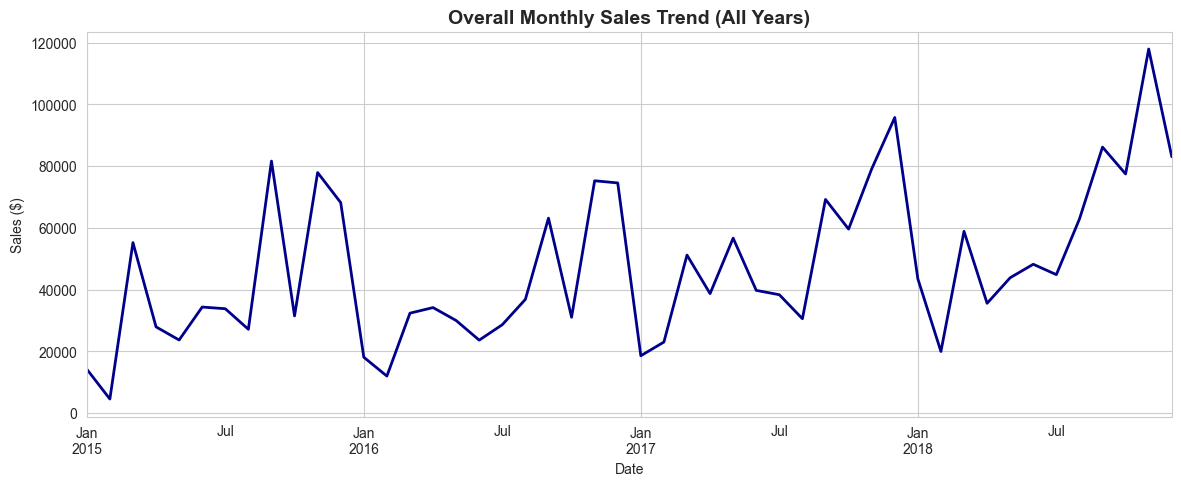

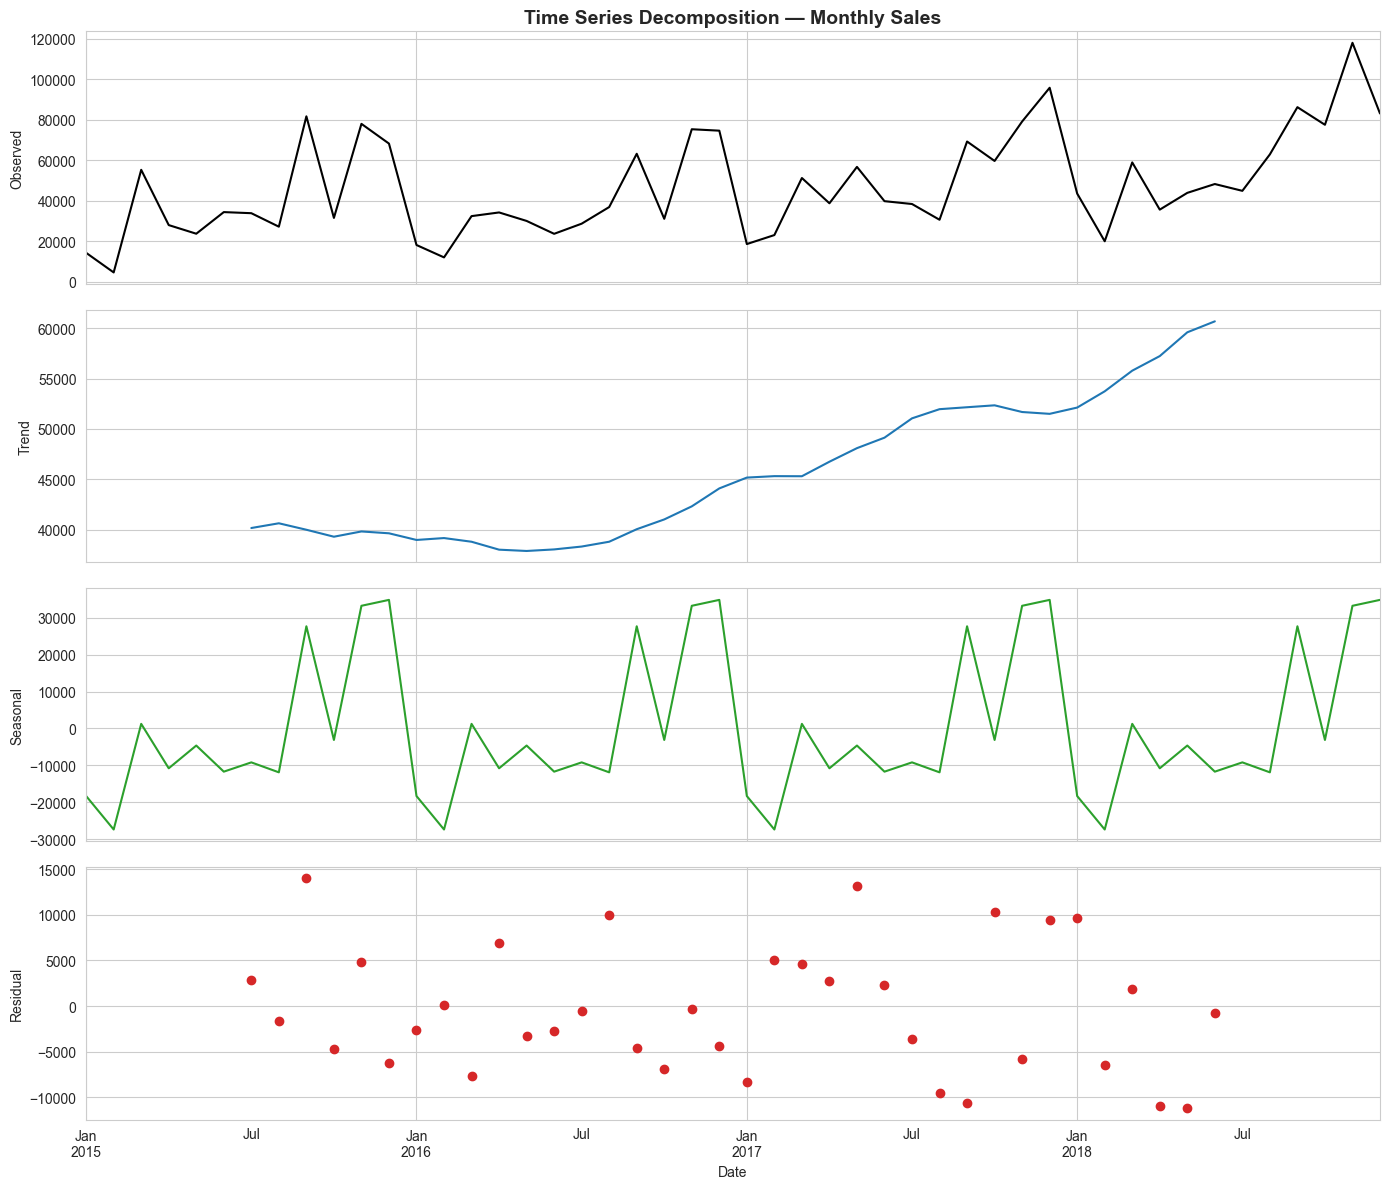

--- ADF Test: Original Series ---
ADF Statistic: -4.4161 | p-value: 0.0003
✅ Stationary



In [3]:
# ================================================================
# TASK 2 — TIME SERIES ANALYSIS & DECOMPOSITION
# ================================================================

ts = monthly_sales.set_index("Date")["Sales"]

fig, ax = plt.subplots(figsize=(14,5))
ts.plot(ax=ax, color="darkblue", linewidth=2)
ax.set_title("Overall Monthly Sales Trend (All Years)")
ax.set_ylabel("Sales ($)")
plt.show()

decomposition = seasonal_decompose(ts, model="additive", period=12)
fig, axes = plt.subplots(4,1, figsize=(14,12), sharex=True)
decomposition.observed.plot(ax=axes[0], color="black"); axes[0].set_ylabel("Observed")
decomposition.trend.plot(ax=axes[1], color="tab:blue"); axes[1].set_ylabel("Trend")
decomposition.seasonal.plot(ax=axes[2], color="tab:green"); axes[2].set_ylabel("Seasonal")
decomposition.resid.plot(ax=axes[3], color="tab:red", marker="o", linestyle="none"); axes[3].set_ylabel("Residual")
axes[0].set_title("Time Series Decomposition — Monthly Sales")
plt.tight_layout()
plt.show()

def adf_test(series, name=""):
    result = adfuller(series.dropna())
    print(f"--- ADF Test: {name} ---")
    print(f"ADF Statistic: {result[0]:.4f} | p-value: {result[1]:.4f}")
    print("✅ Stationary" if result[1] < 0.05 else "❌ Non-Stationary")
    print()
    return result[1]

p_original = adf_test(ts, "Original Series")
if p_original >= 0.05:
    ts_diff = ts.diff().dropna()
    adf_test(ts_diff, "Differenced Series (d=1)")
    fig, ax = plt.subplots()
    ts_diff.plot(ax=ax, color="purple")
    ax.set_title("Differenced Series (d=1)")
    plt.show()


d:\Python\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
d:\Python\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


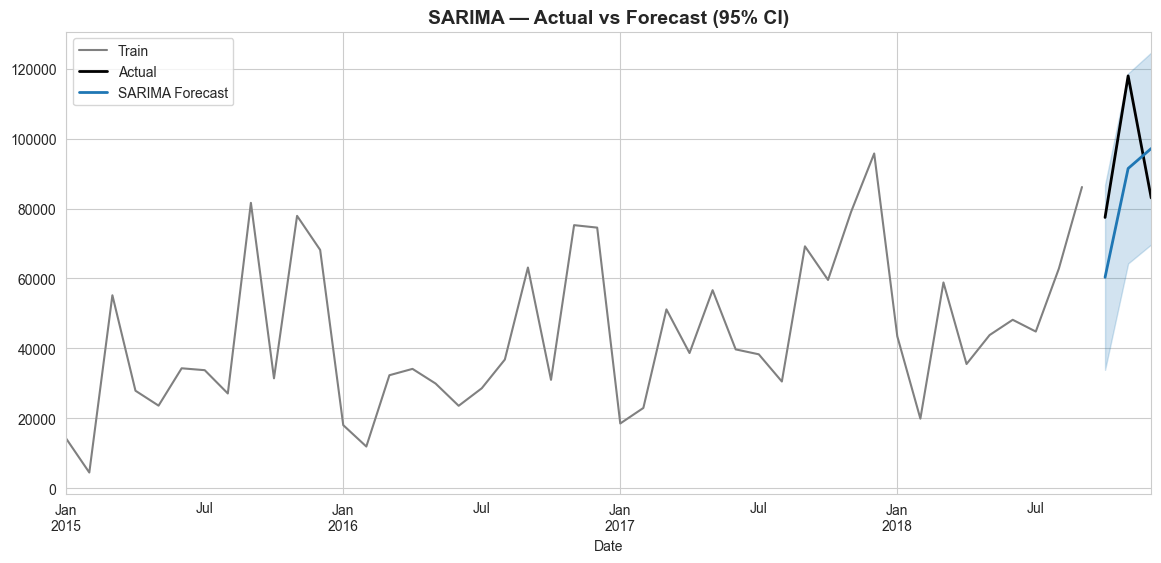

00:06:08 - cmdstanpy - INFO - Chain [1] start processing
00:06:09 - cmdstanpy - INFO - Chain [1] done processing


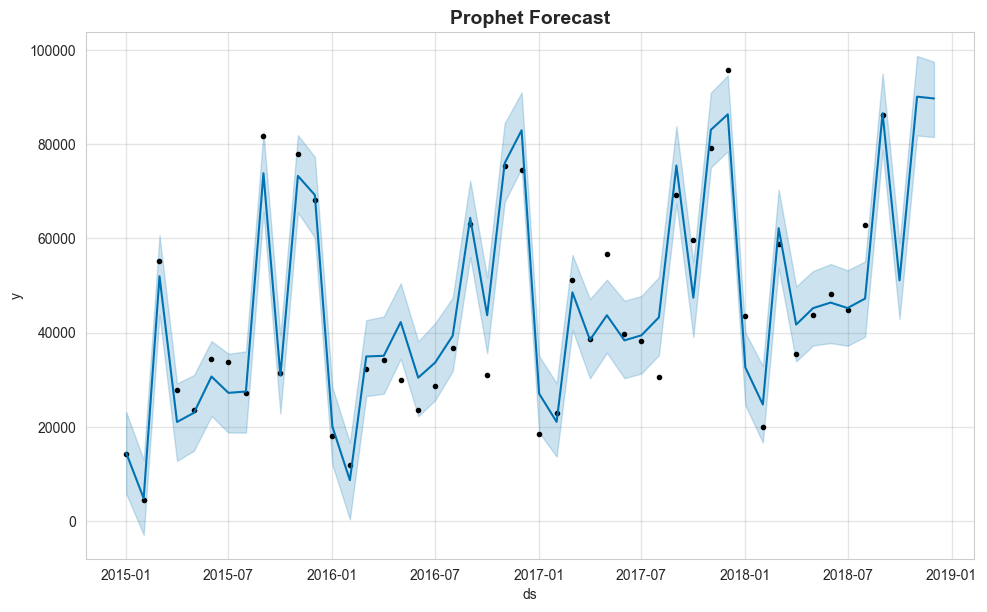

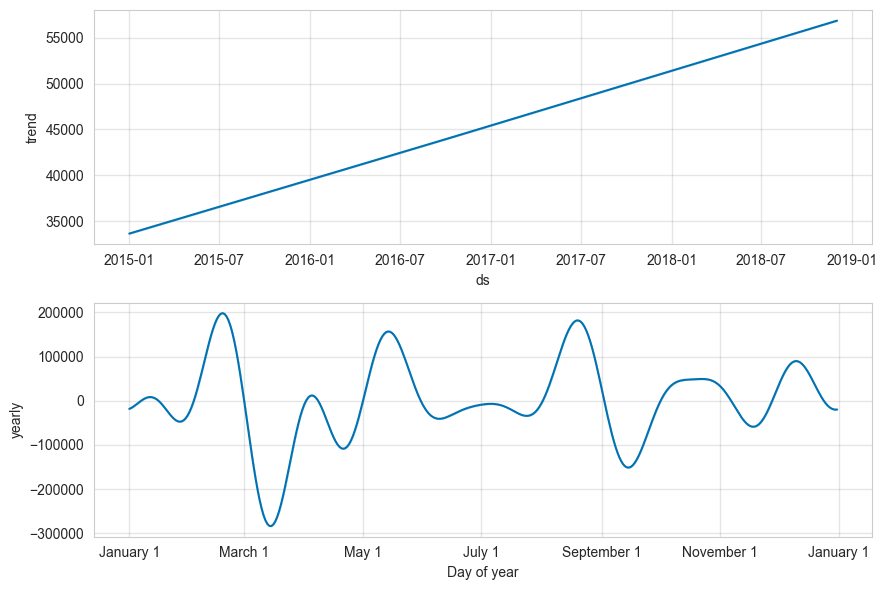

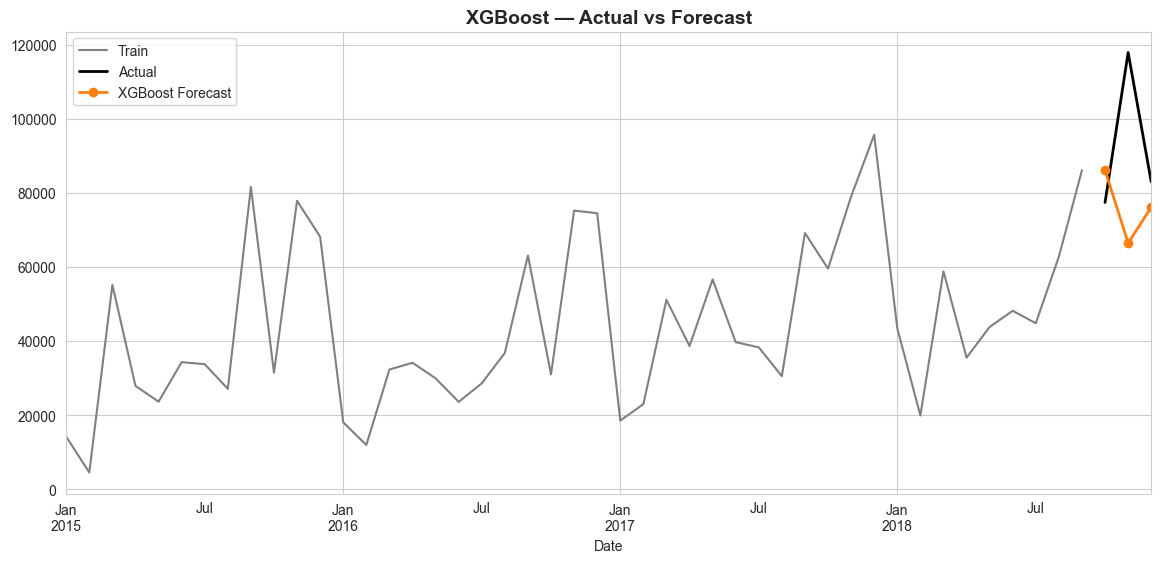

              MAE      RMSE  MAPE (%)   Forecast M1   Forecast M2  \
SARIMA   19244.49  19950.07     20.53  60331.790000  91458.220000   
Prophet  20296.01  22487.47     21.89  51083.660000  90045.400000   
XGBoost  22361.16  30400.84     21.07  86172.476562  66469.296875   

          Forecast M3  
SARIMA   97167.570000  
Prophet  89661.190000  
XGBoost  76140.101562  

🏆 Recommended model for production: SARIMA (lowest RMSE)


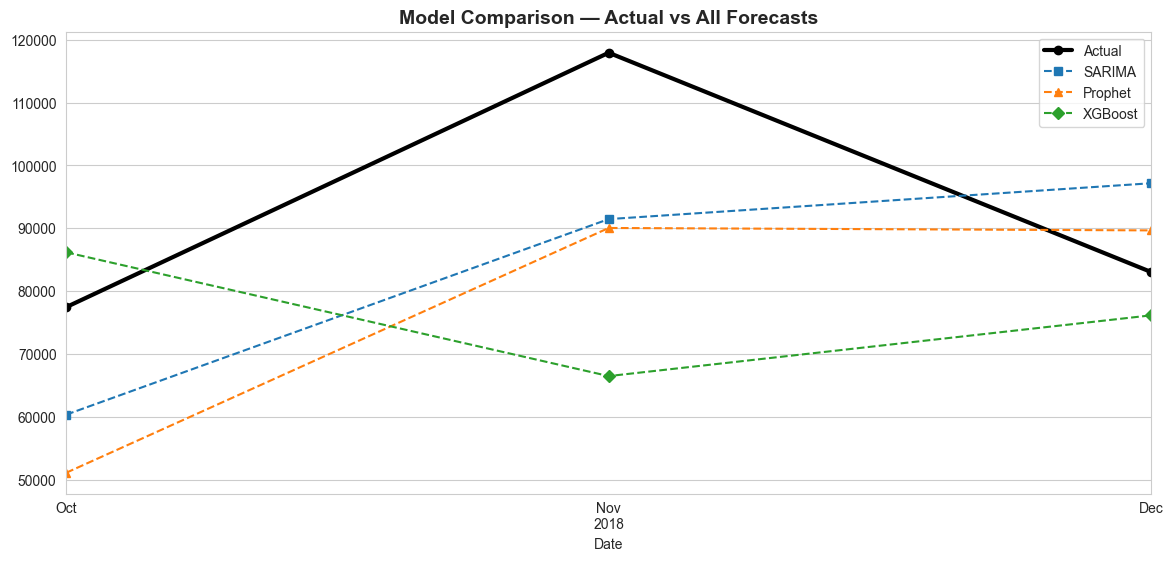

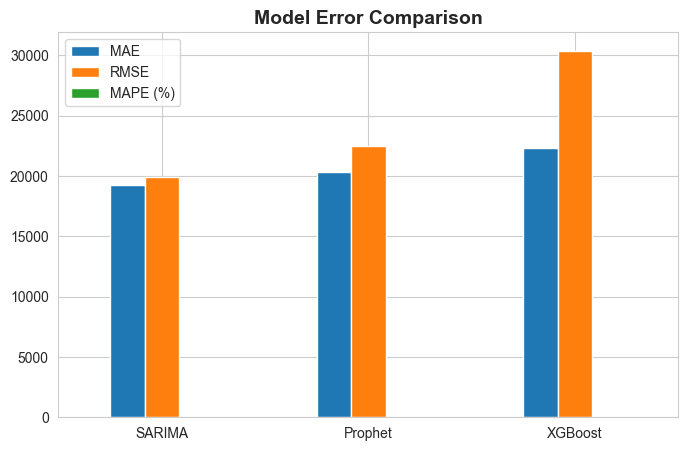

In [4]:
# ================================================================
# TASK 3 — FORECASTING: SARIMA vs PROPHET vs XGBOOST
# ================================================================

train, test = ts[:-3], ts[-3:]

def mape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

results = {}

# ---------- MODEL 1: SARIMA ----------
sarima_fit = SARIMAX(train, order=(1,1,1), seasonal_order=(1,1,1,12),
                      enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
sarima_fc = sarima_fit.get_forecast(steps=3)
sarima_pred, sarima_ci = sarima_fc.predicted_mean, sarima_fc.conf_int()

results["SARIMA"] = {"MAE": mean_absolute_error(test, sarima_pred),
                      "RMSE": np.sqrt(mean_squared_error(test, sarima_pred)),
                      "MAPE": mape(test, sarima_pred), "Forecast": sarima_pred.values}

fig, ax = plt.subplots(figsize=(14,6))
train.plot(ax=ax, label="Train", color="gray")
test.plot(ax=ax, label="Actual", color="black", linewidth=2)
sarima_pred.plot(ax=ax, label="SARIMA Forecast", color="tab:blue", linewidth=2)
ax.fill_between(sarima_ci.index, sarima_ci.iloc[:,0], sarima_ci.iloc[:,1], color="tab:blue", alpha=0.2)
ax.set_title("SARIMA — Actual vs Forecast (95% CI)"); ax.legend()
plt.show()

# ---------- MODEL 2: PROPHET ----------
prophet_df = train.reset_index(); prophet_df.columns = ["ds","y"]
prophet_model = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
prophet_model.fit(prophet_df)
future = prophet_model.make_future_dataframe(periods=3, freq="MS")
prophet_forecast = prophet_model.predict(future)
prophet_pred = prophet_forecast.set_index("ds")["yhat"].iloc[-3:]

results["Prophet"] = {"MAE": mean_absolute_error(test, prophet_pred),
                       "RMSE": np.sqrt(mean_squared_error(test, prophet_pred)),
                       "MAPE": mape(test, prophet_pred), "Forecast": prophet_pred.values}

fig1 = prophet_model.plot(prophet_forecast); plt.title("Prophet Forecast"); plt.show()
fig2 = prophet_model.plot_components(prophet_forecast); plt.show()

# ---------- MODEL 3: XGBOOST ----------
def create_features(series):
    d = series.to_frame("Sales")
    d["Lag1"] = d["Sales"].shift(1)
    d["Lag2"] = d["Sales"].shift(2)
    d["Lag3"] = d["Sales"].shift(3)
    d["RollingMean3"] = d["Sales"].shift(1).rolling(3).mean()
    d["Month"] = d.index.month
    d["Quarter"] = d.index.quarter
    d["Season"] = d["Month"].apply(get_season)
    d = pd.get_dummies(d, columns=["Season"])
    return d

full_feat = create_features(ts).dropna()
feature_cols = [c for c in full_feat.columns if c != "Sales"]

X_train = full_feat.loc[train.index[3]:train.index[-1], feature_cols]
y_train = full_feat.loc[train.index[3]:train.index[-1], "Sales"]

xgb_model = XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=4,
                          subsample=0.8, colsample_bytree=0.8, random_state=RANDOM_STATE)
xgb_model.fit(X_train, y_train)

history = train.copy()
xgb_forecasts = []
for _ in range(3):
    feat_row = create_features(history).iloc[[-1]][feature_cols]
    pred = xgb_model.predict(feat_row)[0]
    xgb_forecasts.append(pred)
    next_date = history.index[-1] + pd.DateOffset(months=1)
    history.loc[next_date] = pred

xgb_pred = pd.Series(xgb_forecasts, index=test.index)
results["XGBoost"] = {"MAE": mean_absolute_error(test, xgb_pred),
                       "RMSE": np.sqrt(mean_squared_error(test, xgb_pred)),
                       "MAPE": mape(test, xgb_pred), "Forecast": xgb_pred.values}

fig, ax = plt.subplots(figsize=(14,6))
train.plot(ax=ax, label="Train", color="gray")
test.plot(ax=ax, label="Actual", color="black", linewidth=2)
xgb_pred.plot(ax=ax, label="XGBoost Forecast", color="tab:orange", linewidth=2, marker="o")
ax.set_title("XGBoost — Actual vs Forecast"); ax.legend()
plt.show()

# ---------- MODEL COMPARISON TABLE ----------
comparison_df = pd.DataFrame({
    model: {"MAE": round(v["MAE"],2), "RMSE": round(v["RMSE"],2), "MAPE (%)": round(v["MAPE"],2),
            "Forecast M1": round(v["Forecast"][0],2), "Forecast M2": round(v["Forecast"][1],2),
            "Forecast M3": round(v["Forecast"][2],2)}
    for model, v in results.items()
}).T
print(comparison_df)

best_model = comparison_df["RMSE"].astype(float).idxmin()
print(f"\n🏆 Recommended model for production: {best_model} (lowest RMSE)")

fig, ax = plt.subplots(figsize=(14,6))
test.plot(ax=ax, label="Actual", color="black", linewidth=3, marker="o")
sarima_pred.plot(ax=ax, label="SARIMA", linestyle="--", marker="s")
prophet_pred.plot(ax=ax, label="Prophet", linestyle="--", marker="^")
xgb_pred.plot(ax=ax, label="XGBoost", linestyle="--", marker="D")
ax.set_title("Model Comparison — Actual vs All Forecasts"); ax.legend()
plt.show()

fig, ax = plt.subplots(figsize=(8,5))
comparison_df[["MAE","RMSE","MAPE (%)"]].astype(float).plot(kind="bar", ax=ax)
ax.set_title("Model Error Comparison"); plt.xticks(rotation=0)
plt.show()


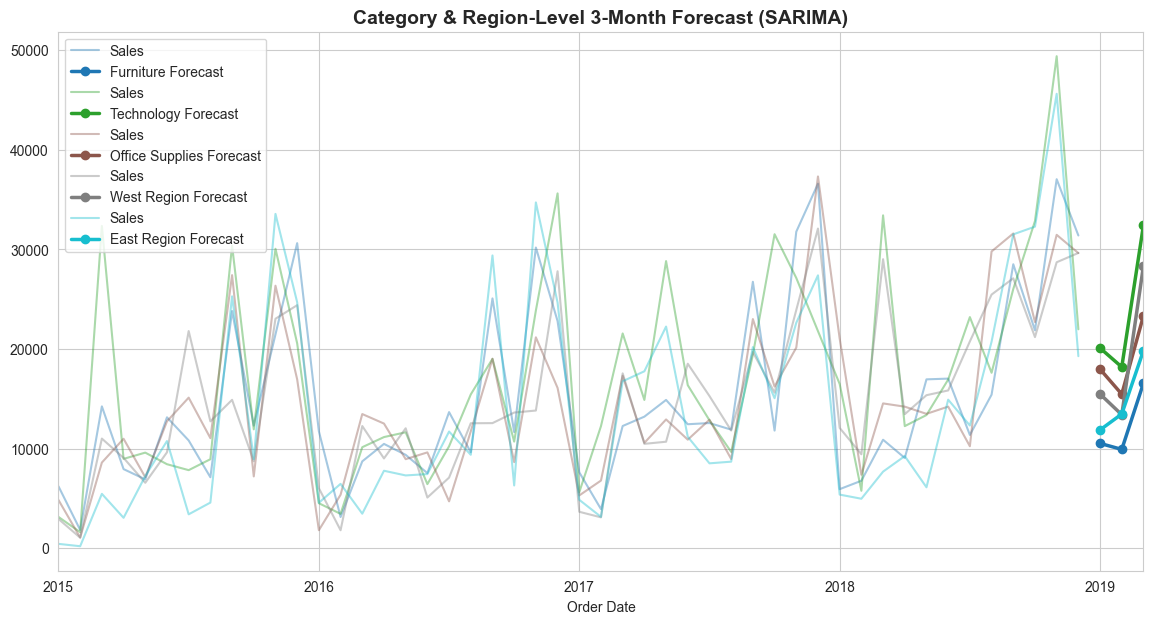

Technology        -17.312715
West Region       -25.124832
Office Supplies   -26.939115
East Region       -44.122088
Furniture         -49.162089
dtype: float64

📈 Strongest projected growth: Technology (-17.3%)


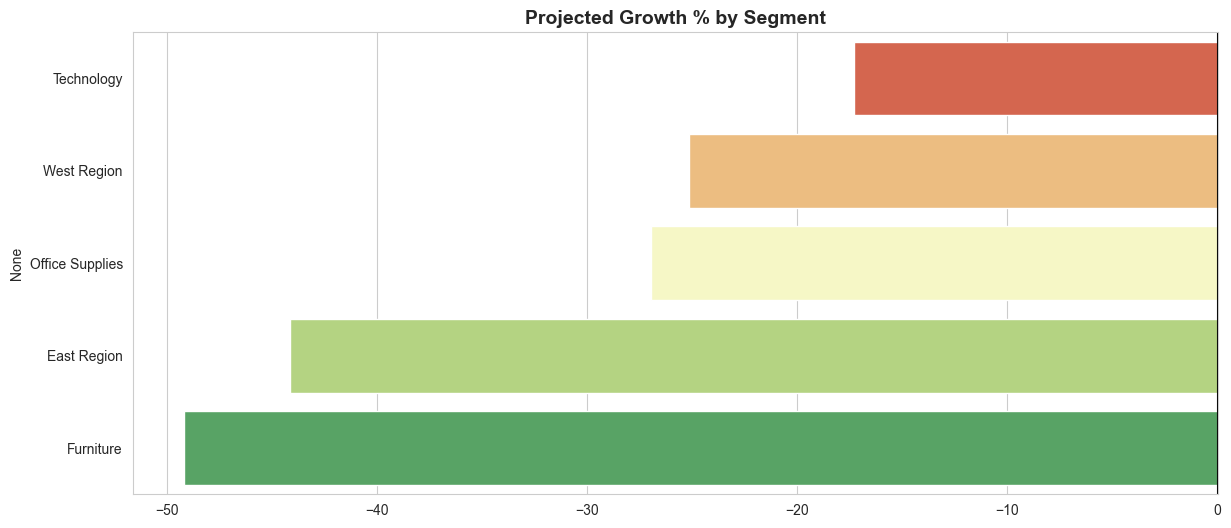

In [5]:
# ================================================================
# TASK 4 — CATEGORY & REGION-LEVEL FORECASTING (using best_model)
# ================================================================

def get_monthly_series(sub_df):
    s = sub_df.groupby("Order Date")["Sales"].sum().reset_index()
    return s.resample("MS", on="Order Date")["Sales"].sum()

def forecast_series(series, model_name, steps=3):
    if model_name == "SARIMA":
        m = SARIMAX(series, order=(1,1,1), seasonal_order=(1,1,1,12),
                    enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
        fc = m.get_forecast(steps=steps).predicted_mean
        fc.index = pd.date_range(series.index[-1]+pd.DateOffset(months=1), periods=steps, freq="MS")
        return fc
    elif model_name == "Prophet":
        pdf = series.reset_index(); pdf.columns = ["ds","y"]
        m = Prophet(yearly_seasonality=True).fit(pdf)
        fut = m.make_future_dataframe(periods=steps, freq="MS")
        return m.predict(fut).set_index("ds")["yhat"].iloc[-steps:]
    else:
        hist = series.copy()
        feat_full = create_features(hist).dropna()
        if len(feat_full) < 6:
            return pd.Series([hist.mean()]*steps,
                index=pd.date_range(hist.index[-1]+pd.DateOffset(months=1), periods=steps, freq="MS"))
        Xf, yf = feat_full[feature_cols], feat_full["Sales"]
        mdl = XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=3, random_state=RANDOM_STATE)
        mdl.fit(Xf, yf)
        preds = []
        for _ in range(steps):
            row = create_features(hist).iloc[[-1]][feature_cols]
            p = mdl.predict(row)[0]
            preds.append(p)
            hist.loc[hist.index[-1] + pd.DateOffset(months=1)] = p
        return pd.Series(preds, index=pd.date_range(series.index[-1]+pd.DateOffset(months=1), periods=steps, freq="MS"))

segments = {
    "Furniture": df[df["Category"]=="Furniture"],
    "Technology": df[df["Category"]=="Technology"],
    "Office Supplies": df[df["Category"]=="Office Supplies"],
    "West Region": df[df["Region"]=="West"],
    "East Region": df[df["Region"]=="East"],
}

segment_forecasts = {}
fig, ax = plt.subplots(figsize=(14,7))
colors = plt.cm.tab10(np.linspace(0,1,len(segments)))
for (name, sub), color in zip(segments.items(), colors):
    s = get_monthly_series(sub)
    fc = forecast_series(s, best_model, steps=3)
    segment_forecasts[name] = fc
    s.plot(ax=ax, color=color, alpha=0.4)
    fc.plot(ax=ax, color=color, linewidth=2.5, marker="o", label=f"{name} Forecast")
ax.set_title(f"Category & Region-Level 3-Month Forecast ({best_model})"); ax.legend()
plt.show()

growth_summary = {}
for name, fc in segment_forecasts.items():
    hist_avg = get_monthly_series(segments[name])[-6:].mean()
    growth_summary[name] = ((fc.mean() - hist_avg)/hist_avg)*100

growth_df = pd.Series(growth_summary).sort_values(ascending=False)
print(growth_df)
print(f"\n📈 Strongest projected growth: {growth_df.idxmax()} ({growth_df.max():.1f}%)")

fig, ax = plt.subplots()
sns.barplot(x=growth_df.values, y=growth_df.index, palette="RdYlGn", ax=ax)
ax.set_title("Projected Growth % by Segment"); ax.axvline(0, color="black")
plt.show()


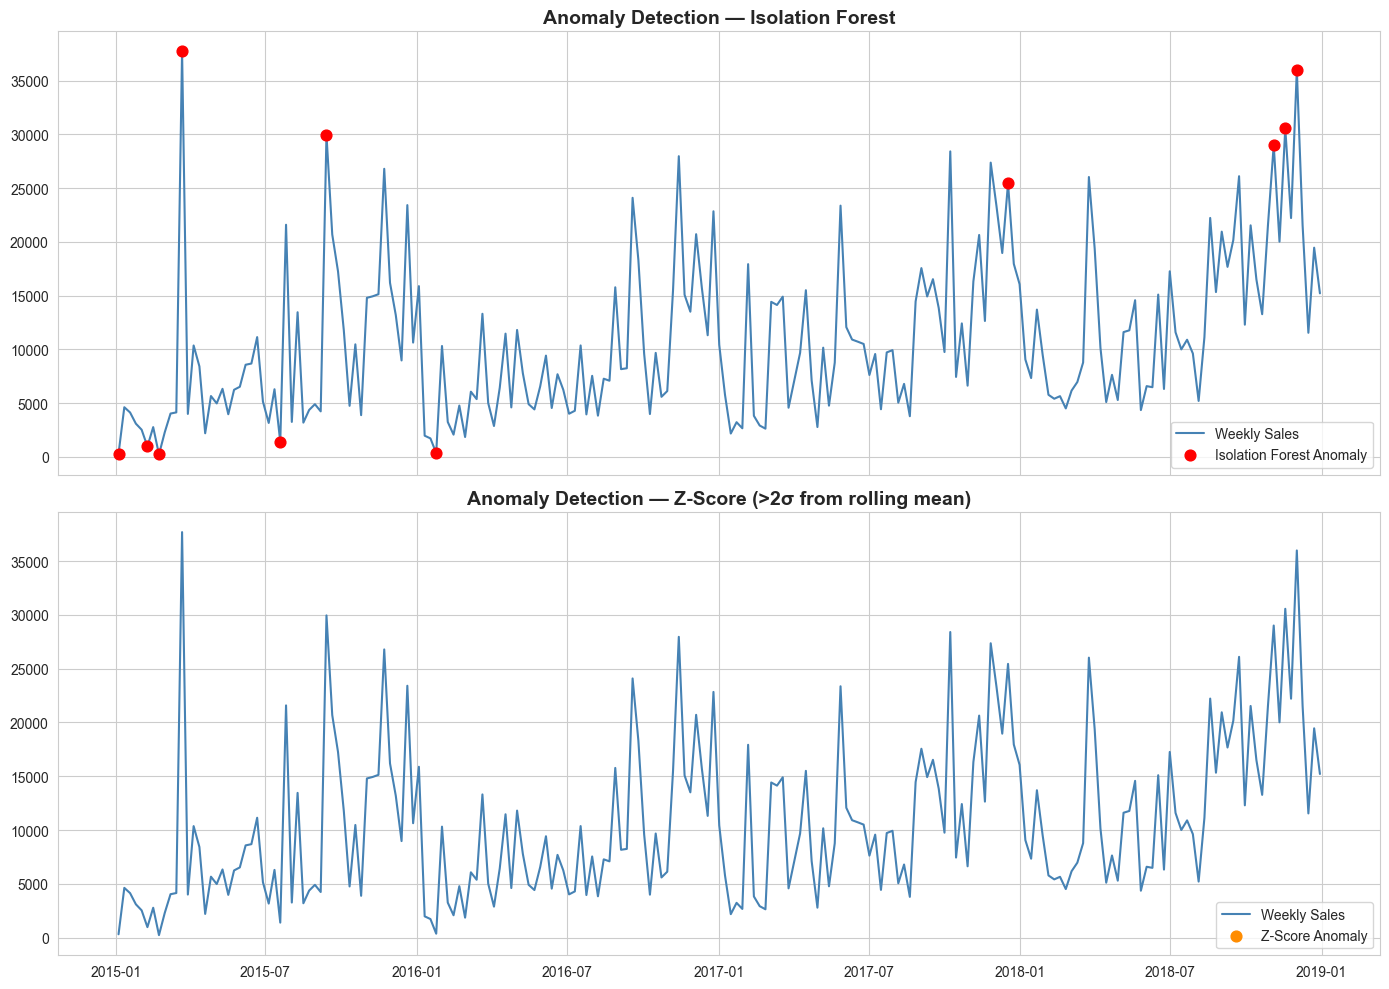

Isolation Forest flagged 11 anomalies
Z-Score method flagged 0 anomalies
Anomalies flagged by BOTH methods: 0

Top anomaly weeks with likely explanations:
2015-03-22 | Sales: 37704 | 📦 Possible bulk/corporate order or promotional event
2018-12-02 | Sales: 35999 | 🎄 Likely holiday/festive season spike
2018-11-18 | Sales: 30572 | 🎄 Likely holiday/festive season spike
2015-09-13 | Sales: 29959 | 📦 Possible bulk/corporate order or promotional event
2018-11-04 | Sales: 29017 | 🎄 Likely holiday/festive season spike


In [6]:

# ================================================================
# TASK 5 — ANOMALY DETECTION
# ================================================================

anomaly_df = weekly_sales.set_index("Date").copy()

iso = IsolationForest(contamination=0.05, random_state=RANDOM_STATE)
anomaly_df["IsoAnomaly"] = iso.fit_predict(anomaly_df[["Sales"]])
anomaly_df["IsoAnomaly"] = anomaly_df["IsoAnomaly"].map({1:0, -1:1})

anomaly_df["RollingMean"] = anomaly_df["Sales"].rolling(4, min_periods=1).mean()
anomaly_df["RollingStd"] = anomaly_df["Sales"].rolling(4, min_periods=1).std()
anomaly_df["ZScore"] = (anomaly_df["Sales"] - anomaly_df["RollingMean"]) / anomaly_df["RollingStd"]
anomaly_df["ZAnomaly"] = (anomaly_df["ZScore"].abs() > 2).astype(int)

fig, axes = plt.subplots(2,1, figsize=(14,10), sharex=True)
axes[0].plot(anomaly_df.index, anomaly_df["Sales"], color="steelblue", label="Weekly Sales")
iso_pts = anomaly_df[anomaly_df["IsoAnomaly"]==1]
axes[0].scatter(iso_pts.index, iso_pts["Sales"], color="red", s=60, zorder=5, label="Isolation Forest Anomaly")
axes[0].set_title("Anomaly Detection — Isolation Forest"); axes[0].legend()

axes[1].plot(anomaly_df.index, anomaly_df["Sales"], color="steelblue", label="Weekly Sales")
z_pts = anomaly_df[anomaly_df["ZAnomaly"]==1]
axes[1].scatter(z_pts.index, z_pts["Sales"], color="darkorange", s=60, zorder=5, label="Z-Score Anomaly")
axes[1].set_title("Anomaly Detection — Z-Score (>2σ from rolling mean)"); axes[1].legend()
plt.tight_layout(); plt.show()

print(f"Isolation Forest flagged {anomaly_df['IsoAnomaly'].sum()} anomalies")
print(f"Z-Score method flagged {anomaly_df['ZAnomaly'].sum()} anomalies")
agreement = ((anomaly_df["IsoAnomaly"]==1) & (anomaly_df["ZAnomaly"]==1)).sum()
print(f"Anomalies flagged by BOTH methods: {agreement}")

print("\nTop anomaly weeks with likely explanations:")
for date, row in iso_pts.sort_values("Sales", ascending=False).head(5).iterrows():
    month = date.month_name()
    if month in ["November","December"]:
        note = "🎄 Likely holiday/festive season spike"
    elif row["Sales"] > anomaly_df["Sales"].mean()*1.5:
        note = "📦 Possible bulk/corporate order or promotional event"
    else:
        note = "📉 Possible supply disruption or low-demand week"
    print(f"{date.date()} | Sales: {row['Sales']:.0f} | {note}")



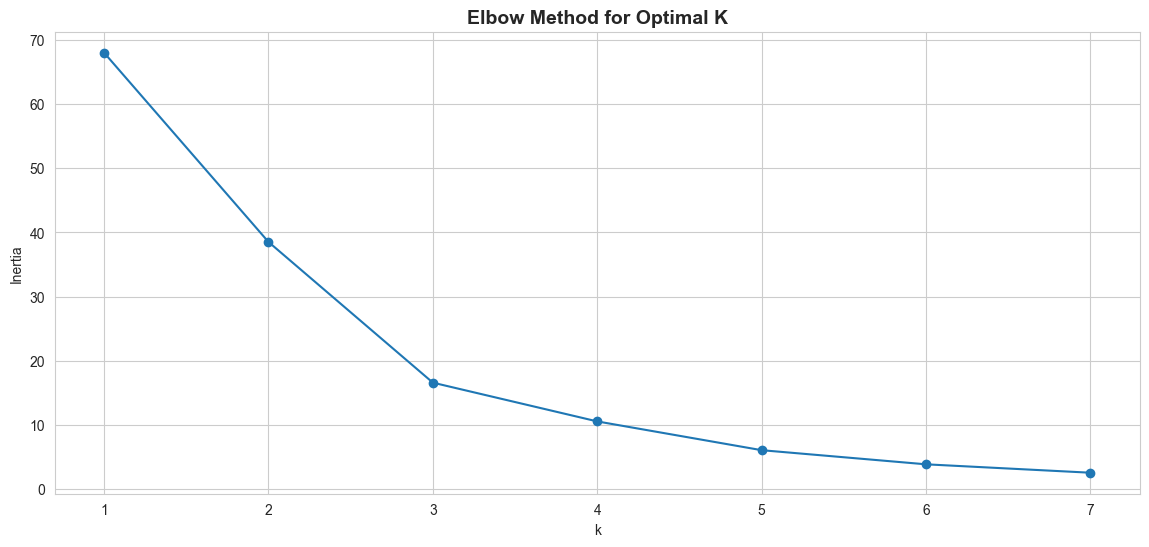

   Sub-Category                ClusterLabel   TotalSales  GrowthRate
11     Machines            Declining Demand  189238.6310  -29.793120
8     Fasteners              Growing Demand    3001.9600   30.468364
1    Appliances              Growing Demand  104618.4030  165.242912
2           Art              Growing Demand   26705.4100   49.649531
4     Bookcases              Growing Demand  113813.1987   49.846598
6       Copiers              Growing Demand  146248.0940  479.729510
7     Envelopes              Growing Demand   16128.0460  -12.121345
15     Supplies              Growing Demand   46420.3080   11.276038
9   Furnishings              Growing Demand   89212.0180  106.824969
10       Labels              Growing Demand   12347.7260   36.073373
12        Paper              Growing Demand   76828.3040   91.901971
14      Storage  High Volume, Stable Demand  219343.3920   38.366108
13       Phones  High Volume, Stable Demand  327782.4480   35.557607
0   Accessories  High Volume, Stab

In [7]:
# ================================================================
# TASK 6 — PRODUCT DEMAND SEGMENTATION (K-MEANS + PCA)
# ================================================================

sub_cat = df.groupby("Sub-Category").apply(lambda g: pd.Series({
    "TotalSales": g["Sales"].sum(),
    "AvgOrderValue": g["Sales"].mean(),
    "Volatility": g.groupby(g["Order Date"].dt.to_period("M"))["Sales"].sum().std(),
})).reset_index()

yoy = df.groupby(["Sub-Category","Year"])["Sales"].sum().reset_index()
def compute_growth(g):
    g = g.sort_values("Year")
    if len(g) < 2 or g["Sales"].iloc[0] == 0: return 0
    return ((g["Sales"].iloc[-1] - g["Sales"].iloc[0]) / g["Sales"].iloc[0]) * 100
growth_rate = yoy.groupby("Sub-Category").apply(compute_growth).reset_index()
growth_rate.columns = ["Sub-Category","GrowthRate"]

cluster_features = sub_cat.merge(growth_rate, on="Sub-Category").fillna(0)
X = cluster_features[["TotalSales","AvgOrderValue","Volatility","GrowthRate"]]
X_scaled = StandardScaler().fit_transform(X)

inertias = []
K_range = range(1,8)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10).fit(X_scaled)
    inertias.append(km.inertia_)

fig, ax = plt.subplots()
ax.plot(K_range, inertias, marker="o")
ax.set_xlabel("k"); ax.set_ylabel("Inertia"); ax.set_title("Elbow Method for Optimal K")
plt.show()

optimal_k = 4
kmeans = KMeans(n_clusters=optimal_k, random_state=RANDOM_STATE, n_init=10)
cluster_features["Cluster"] = kmeans.fit_predict(X_scaled)

pca = PCA(n_components=2, random_state=RANDOM_STATE)
coords = pca.fit_transform(X_scaled)
cluster_features["PCA1"], cluster_features["PCA2"] = coords[:,0], coords[:,1]

cluster_summary = cluster_features.groupby("Cluster")[["TotalSales","GrowthRate","Volatility"]].mean()

def label_cluster(row):
    if row["TotalSales"] > cluster_summary["TotalSales"].median() and row["Volatility"] < cluster_summary["Volatility"].median():
        return "High Volume, Stable Demand"
    elif row["GrowthRate"] > 20:
        return "Growing Demand"
    elif row["GrowthRate"] < 0:
        return "Declining Demand"
    return "Low Volume, High Volatility"

cluster_summary["Label"] = cluster_summary.apply(label_cluster, axis=1)
cluster_features["ClusterLabel"] = cluster_features["Cluster"].map(cluster_summary["Label"].to_dict())

fig = px.scatter(cluster_features, x="PCA1", y="PCA2", color="ClusterLabel",
                  hover_name="Sub-Category", size="TotalSales", size_max=40,
                  title="Product Demand Segments (PCA 2D)")
fig.show()

print(cluster_features[["Sub-Category","ClusterLabel","TotalSales","GrowthRate"]].sort_values("ClusterLabel"))

strategy_map = {
    "High Volume, Stable Demand": "Maintain steady stock levels; automated reorder points; low safety stock needed.",
    "Growing Demand": "Increase stock buffer; scale supply chain; negotiate better supplier terms.",
    "Declining Demand": "Reduce inventory commitment; promote to clear stock; phase out slow movers.",
    "Low Volume, High Volatility": "Keep higher safety stock; flexible/just-in-time sourcing; forecast conservatively."
}
for label, strat in strategy_map.items():
    print(f"\n📦 {label}:\n   → {strat}")

print("\n✅ Tasks 1-6 complete. Save train.csv locally for the Streamlit app (Task 7).")
df.to_csv("train.csv", index=False)